# 4 — Diagnostics and model improvements

Four self-contained experiments, in the order worth running. Each reuses the
v6 dataset (`state_space_datasetV6`) and writes to its own model directory, so
nothing here overwrites `checkpoints/time2success_v6`.

| Section | What it does | Cost | Answers |
|---|---|---|---|
| A | Hand-position ablation | minutes | Is the model keying on absolute hand position? |
| B | Pair-based relative objective | ~10 min | Does predicting *gaps* beat the clock? |
| C | Monotonicity penalty | ~10 min | Can "progress needs the peg moving" be imposed at training time? |
| D | Off-path data | ~1 hr collection | Does the model behave off the demonstration manifold? |

Run A while the policy training is going — it needs no GPU contention and is
the diagnostic that most directly tests why the reward margin is thin.

## 0. Shared setup

In [2]:
import numpy as np
import torch
import torch.nn as nn
import gymnasium as gym
import metaworld
import os, json, pickle, glob, time
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from scipy.stats import spearmanr
from stable_baselines3 import SAC
import matplotlib.pyplot as plt

TASK_NAME = "peg-insert-side-v3"
SUCCESS_KEY = "success"
OBS_DIM = 39
HAND_POS_IDX = [0, 1, 2]
GRIPPER_IDX  = 3
PEG_POS_IDX  = [4, 5, 6]
GOAL_POS_IDX = [36, 37, 38]
LAG_OFFSET   = 18          # dims 18-35 mirror dims 0-17 at the previous step

device = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_DIR = "./data/state_space_datasetV6"
data = np.load(os.path.join(DATASET_DIR, "dataset.npz"))
X, y_steps, episode_ids = data["X"], data["y_steps"], data["episode_ids"]
frame_idxs = data["frame_idxs"]
print(f"{X.shape[0]} rows, {X.shape[1]} dims, {len(np.unique(episode_ids))} episodes")

class Time2SuccessModel(nn.Module):
    def __init__(self, obs_dim, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

9457 rows, 39 dims, 120 episodes


In [3]:
def split_and_normalize(X_in, y_in, groups, test_size=0.15, seed=0):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    tr, va = next(gss.split(X_in, y_in, groups=groups))
    Xtr, ytr, Xva, yva = X_in[tr], y_in[tr], X_in[va], y_in[va]
    xm, xs = Xtr.mean(axis=0), Xtr.std(axis=0) + 1e-8
    ym, ys = ytr.mean(), ytr.std()
    return dict(train_idx=tr, val_idx=va,
                Xtr=(Xtr - xm) / xs, ytr=(ytr - ym) / ys,
                Xva=(Xva - xm) / xs, yva=(yva - ym) / ys,
                x_mean=xm, x_std=xs, y_mean=ym, y_std=ys)

def train_model(Xtr, ytr, Xva, yva, obs_dim, out_dir, epochs=300, patience=30,
                extra_loss=None, seed=0, verbose=True):
    """Standard training loop. `extra_loss(model, xb, yb) -> tensor` is added to
    MSE when provided — used by Section C."""
    os.makedirs(out_dir, exist_ok=True)
    torch.manual_seed(seed); np.random.seed(seed)
    tl = DataLoader(TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                                   torch.tensor(ytr, dtype=torch.float32)),
                     batch_size=256, shuffle=True)
    vl = DataLoader(TensorDataset(torch.tensor(Xva, dtype=torch.float32),
                                   torch.tensor(yva, dtype=torch.float32)), batch_size=256)
    m = Time2SuccessModel(obs_dim=obs_dim).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    mse = nn.MSELoss()
    best, stale = float("inf"), 0
    for ep in range(epochs):
        m.train()
        for xb, yb in tl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = mse(m(xb), yb)
            if extra_loss is not None:
                loss = loss + extra_loss(m, xb, yb)
            loss.backward(); opt.step()
        m.eval(); v = 0.0
        with torch.no_grad():
            for xb, yb in vl:
                xb, yb = xb.to(device), yb.to(device)
                v += mse(m(xb), yb).item() * xb.size(0)
        v /= len(Xva)
        if v < best:
            best, stale = v, 0
            torch.save(m.state_dict(), os.path.join(out_dir, "model.pt"))
        else:
            stale += 1
            if stale >= patience:
                break
    if verbose:
        print(f"  {out_dir}: best val MSE(norm)={best:.4f}, stopped epoch {ep}")
    m.load_state_dict(torch.load(os.path.join(out_dir, "model.pt")))
    m.eval()
    return m, best

In [4]:
FIXED_TASK_PATH = os.path.join(DATASET_DIR, "fixed_task.pkl")

def make_env(seed=0, render_mode=None):
    return gym.make("Meta-World/MT1", env_name=TASK_NAME, seed=seed, render_mode=render_mode)

def find_wrapper(env, attr):
    w = env
    while not hasattr(w, attr):
        if not hasattr(w, "env"):
            raise AttributeError(attr)
        w = w.env
    return w

def make_fixed_scene_env(render_mode=None):
    env = make_env(seed=0, render_mode=render_mode)
    find_wrapper(env, "tasks").toggle_sample_tasks_on_reset(False)
    with open(FIXED_TASK_PATH, "rb") as f:
        env.unwrapped.set_task(pickle.load(f))
    return env

ckpts = sorted(glob.glob("./checkpoints/peg_insert_side/sac_peg_insert_*.zip"),
               key=lambda p: int("".join(c for c in os.path.basename(p) if c.isdigit()) or 0))
FINAL_CKPT = [p for p in ckpts if "final" in os.path.basename(p)][0]
EARLY_CKPT = ckpts[1]

def make_predictor(model, x_mean, x_std, y_mean, y_std, transform=None):
    @torch.no_grad()
    def f(obs):
        v = np.asarray(obs, dtype=np.float32)
        if transform is not None:
            v = transform(v)
        x = torch.tensor((v - x_mean) / x_std, dtype=torch.float32).unsqueeze(0).to(device)
        return float(model(x).item() * y_std + y_mean)
    return f

def rollout_preds(policy, predict_fn, max_steps=500, deterministic=True, random_policy=False):
    env = make_fixed_scene_env()
    obs, _ = env.reset()
    preds, success = [], None
    for t in range(max_steps):
        preds.append(predict_fn(obs))
        a = env.action_space.sample() if random_policy else policy.predict(obs, deterministic=deterministic)[0]
        obs, _, term, trunc, info = env.step(a)
        if info.get(SUCCESS_KEY, 0) and success is None:
            success = t
        if term or trunc:
            break
    env.close()
    return np.array(preds), success

## A. Hand-position ablation

**Claim being tested:** the model keys on absolute hand position rather than on
the hand-peg relationship, because in successful-only data those are perfectly
correlated — the peg sits still until grasp, then moves with the hand.

**Method:** zero out the hand-position columns (0-2) and their lagged copies
(18-20), retrain identically, and compare. If the ablated model behaves *more*
sensibly on a hovering rollout, absolute hand position was the shortcut. If it
behaves the same or worse, the explanation is wrong and the next sections are
better targets.

In [8]:
ABLATE_IDX = HAND_POS_IDX + [i + LAG_OFFSET for i in HAND_POS_IDX]
print("zeroing dims:", ABLATE_IDX)

X_abl = X.copy()
X_abl[:, ABLATE_IDX] = 0.0

s_full = split_and_normalize(X,     y_steps, episode_ids)
s_abl  = split_and_normalize(X_abl, y_steps, episode_ids)

m_full, v_full = train_model(s_full["Xtr"], s_full["ytr"], s_full["Xva"], s_full["yva"],
                              OBS_DIM, "./checkpoints/t2s_ablation_full")
m_abl,  v_abl  = train_model(s_abl["Xtr"],  s_abl["ytr"],  s_abl["Xva"],  s_abl["yva"],
                              OBS_DIM, "./checkpoints/t2s_ablation_nohand")

print(f"\nval MSE  full={v_full:.4f}   no-hand={v_abl:.4f}")
print("If no-hand is only slightly worse, hand position was largely redundant —")
print("the model could have used the peg relationship all along and chose not to.")

zeroing dims: [0, 1, 2, 18, 19, 20]
  ./checkpoints/t2s_ablation_full: best val MSE(norm)=0.0187, stopped epoch 213
  ./checkpoints/t2s_ablation_nohand: best val MSE(norm)=0.0952, stopped epoch 250

val MSE  full=0.0187   no-hand=0.0952
If no-hand is only slightly worse, hand position was largely redundant —
the model could have used the peg relationship all along and chose not to.


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


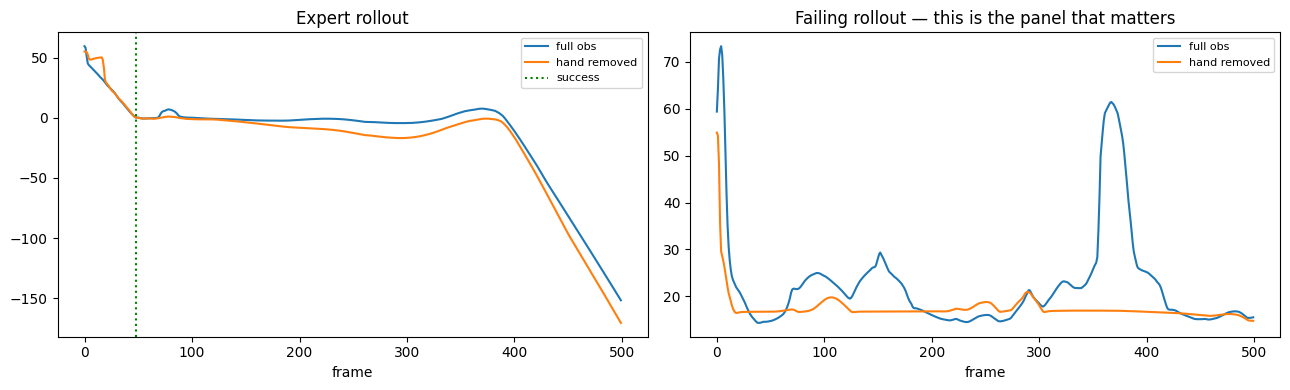

failing rollout, minimum predicted steps:
  full obs    : 14.3   (lower = model thinks a stalled arm is near success)
  hand removed: 14.8


In [9]:
pred_full = make_predictor(m_full, s_full["x_mean"], s_full["x_std"],
                            s_full["y_mean"], s_full["y_std"])
pred_abl  = make_predictor(m_abl, s_abl["x_mean"], s_abl["x_std"],
                            s_abl["y_mean"], s_abl["y_std"],
                            transform=lambda v: np.where(
                                np.isin(np.arange(len(v)), ABLATE_IDX), 0.0, v).astype(np.float32))

expert_pol, early_pol = SAC.load(FINAL_CKPT), SAC.load(EARLY_CKPT)
p_exp_full, s_exp = rollout_preds(expert_pol, pred_full)
p_exp_abl,  _     = rollout_preds(expert_pol, pred_abl)
p_fail_full, _    = rollout_preds(early_pol, pred_full)
p_fail_abl,  _    = rollout_preds(early_pol, pred_abl)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(p_exp_full, label="full obs"); axes[0].plot(p_exp_abl, label="hand removed")
axes[0].axvline(s_exp, color="green", ls=":", label="success")
axes[0].set_title("Expert rollout"); axes[0].legend(fontsize=8); axes[0].set_xlabel("frame")
axes[1].plot(p_fail_full, label="full obs"); axes[1].plot(p_fail_abl, label="hand removed")
axes[1].set_title("Failing rollout — this is the panel that matters")
axes[1].legend(fontsize=8); axes[1].set_xlabel("frame")
plt.tight_layout(); plt.show()

print(f"failing rollout, minimum predicted steps:")
print(f"  full obs    : {p_fail_full.min():.1f}   (lower = model thinks a stalled arm is near success)")
print(f"  hand removed: {p_fail_abl.min():.1f}")

**Reading it.** The failing rollout previously bottomed out around 11
predicted steps — the model rating a permanently stalled arm as nearly done,
which is what made hovering worth 87% of success in the reward inspection.

If the ablated model keeps that rollout high, absolute hand position was the
shortcut and removing it (or decorrelating it) is a real fix. If it also
bottoms out near 11, the shortcut is elsewhere and Sections B/C are the better
bet.

## B. Pair-based relative objective

**Why:** the clock baseline predicted your labels to 93-97% skill, so per-frame
absolute regression can be satisfied by learning position-along-the-one-path.
RynnValue's relative head sidesteps this by predicting the *gap between two
sampled frames* rather than a value for one frame. A clock cannot answer that
from a single state — the model must compare two states.

**Method:** train on pairs (s_i, s_j) drawn non-consecutively from the same
episode, targeting `label_i - label_j`. Prediction at deployment stays
per-state; only the training objective changes.

In [5]:
class RelativeT2SModel(nn.Module):
    """Shares one encoder; scores each state, and the *difference* of scores is
    trained against the label gap. Absolute scale is fixed by an anchor term so
    the output stays interpretable as steps-remaining."""
    def __init__(self, obs_dim, hidden=256, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

def make_pairs(episode_ids_arr, n_pairs_per_ep=400, min_gap=1, seed=0):
    """Random non-consecutive index pairs from within the same episode."""
    rng = np.random.default_rng(seed)
    I, J = [], []
    for ep in np.unique(episode_ids_arr):
        rows = np.where(episode_ids_arr == ep)[0]
        if len(rows) < min_gap + 2:
            continue
        a = rng.choice(rows, size=n_pairs_per_ep)
        b = rng.choice(rows, size=n_pairs_per_ep)
        keep = np.abs(a - b) >= min_gap
        I.append(a[keep]); J.append(b[keep])
    return np.concatenate(I), np.concatenate(J)

In [6]:
s = split_and_normalize(X, y_steps, episode_ids)
tr_rows, va_rows = s["train_idx"], s["val_idx"]

Xn = (X - s["x_mean"]) / s["x_std"]
yn = (y_steps - s["y_mean"]) / s["y_std"]

I_tr, J_tr = make_pairs(episode_ids[tr_rows], n_pairs_per_ep=400)
I_tr, J_tr = tr_rows[I_tr], tr_rows[J_tr]     # map back to global row indices
print(f"training pairs: {len(I_tr)}")

model_rel = RelativeT2SModel(obs_dim=OBS_DIM).to(device)
opt = torch.optim.Adam(model_rel.parameters(), lr=1e-3, weight_decay=1e-4)
mse = nn.MSELoss()

Xi = torch.tensor(Xn[I_tr], dtype=torch.float32)
Xj = torch.tensor(Xn[J_tr], dtype=torch.float32)
dY = torch.tensor(yn[I_tr] - yn[J_tr], dtype=torch.float32)
Yi = torch.tensor(yn[I_tr], dtype=torch.float32)

ds = TensorDataset(Xi, Xj, dY, Yi)
dl = DataLoader(ds, batch_size=512, shuffle=True)

ANCHOR_W = 0.2      # keeps the absolute scale pinned; relative term does the work
for ep in range(120):
    model_rel.train()
    tot = 0.0
    for xi, xj, dy, yi in dl:
        xi, xj, dy, yi = xi.to(device), xj.to(device), dy.to(device), yi.to(device)
        opt.zero_grad()
        si, sj = model_rel(xi), model_rel(xj)
        loss = mse(si - sj, dy) + ANCHOR_W * mse(si, yi)
        loss.backward(); opt.step()
        tot += loss.item() * xi.size(0)
    if ep % 20 == 0:
        print(f"  epoch {ep}: loss={tot/len(ds):.4f}")

os.makedirs("./checkpoints/t2s_relative", exist_ok=True)
torch.save(model_rel.state_dict(), "./checkpoints/t2s_relative/model.pt")
np.savez("./checkpoints/t2s_relative/normalization.npz",
         X_mean=s["x_mean"], X_std=s["x_std"], y_mean=s["y_mean"], y_std=s["y_std"])
print("saved ./checkpoints/t2s_relative")

training pairs: 40280
  epoch 0: loss=0.1761
  epoch 20: loss=0.0408
  epoch 40: loss=0.0358
  epoch 60: loss=0.0342
  epoch 80: loss=0.0330
  epoch 100: loss=0.0326
saved ./checkpoints/t2s_relative


absolute (baseline)   : model MAE=  1.52  clock MAE=  7.85  mean-baseline MAE= 18.48
relative (pairs)      : model MAE=  4.27  clock MAE=  7.85  mean-baseline MAE= 18.48

failing rollout minimum: absolute=14.3  relative=7.0


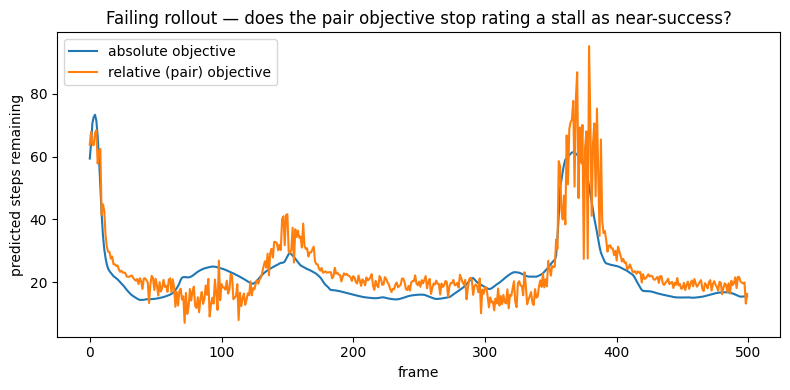

In [10]:
# Did the relative objective reduce the clock shortcut?
def clock_skill(pred_vals, labels, frames):
    """How much of the model's accuracy a pure frame-counter could reproduce."""
    tab = np.zeros(int(frames.max()) + 1, dtype=np.float32)
    for t in range(len(tab)):
        v = labels[frames == t]
        tab[t] = np.median(v) if len(v) else 0.0
    mae_clock = np.abs(tab[frames] - labels).mean()
    mae_model = np.abs(pred_vals - labels).mean()
    mae_mean  = np.abs(labels.mean() - labels).mean()
    return mae_model, mae_clock, mae_mean

pred_rel = make_predictor(model_rel, s["x_mean"], s["x_std"], s["y_mean"], s["y_std"])

@torch.no_grad()
def batch_pred(m, rows):
    x = torch.tensor(Xn[rows], dtype=torch.float32).to(device)
    return (m(x).cpu().numpy() * s["y_std"] + s["y_mean"])

pv_rel  = batch_pred(model_rel, va_rows)
pv_full = batch_pred(m_full,    va_rows)

for name, pv in [("absolute (baseline)", pv_full), ("relative (pairs)", pv_rel)]:
    mm, mc, mb = clock_skill(pv, y_steps[va_rows], frame_idxs[va_rows])
    print(f"{name:22s}: model MAE={mm:6.2f}  clock MAE={mc:6.2f}  mean-baseline MAE={mb:6.2f}")

p_fail_rel, _ = rollout_preds(early_pol, pred_rel)
print(f"\nfailing rollout minimum: absolute={p_fail_full.min():.1f}  relative={p_fail_rel.min():.1f}")

plt.figure(figsize=(8, 4))
plt.plot(p_fail_full, label="absolute objective")
plt.plot(p_fail_rel, label="relative (pair) objective")
plt.xlabel("frame"); plt.ylabel("predicted steps remaining")
plt.title("Failing rollout — does the pair objective stop rating a stall as near-success?")
plt.legend(); plt.tight_layout(); plt.show()

## C. Monotonicity penalty

**Why:** nothing in MSE says progress requires the peg advancing. This adds a
term that penalizes predicting a *decrease* across transitions where the peg
did not get closer to the goal — encoding the constraint directly rather than
hoping the model infers it from correlated features.

**Method:** build consecutive-frame pairs, compute whether peg-to-goal distance
improved, and penalize `pred(s_t) - pred(s_{t+1}) > 0` on the pairs where it
did not.

In [11]:
# consecutive within-episode pairs, plus whether the peg actually advanced
peg_to_goal = np.linalg.norm(X[:, PEG_POS_IDX] - X[:, GOAL_POS_IDX], axis=1)

cons_i, cons_j, advanced = [], [], []
for ep in np.unique(episode_ids):
    rows = np.where(episode_ids == ep)[0]
    for k in range(len(rows) - 1):
        cons_i.append(rows[k]); cons_j.append(rows[k + 1])
        advanced.append(peg_to_goal[rows[k + 1]] < peg_to_goal[rows[k]] - 1e-6)
cons_i = np.array(cons_i); cons_j = np.array(cons_j)
advanced = np.array(advanced)
print(f"consecutive pairs: {len(cons_i)}, peg advanced on {advanced.mean():.1%}")

tr_set = set(tr_rows.tolist())
mask = np.array([i in tr_set and j in tr_set for i, j in zip(cons_i, cons_j)])
Ci = torch.tensor(Xn[cons_i[mask]], dtype=torch.float32).to(device)
Cj = torch.tensor(Xn[cons_j[mask]], dtype=torch.float32).to(device)
Cadv = torch.tensor(advanced[mask].astype(np.float32)).to(device)
print(f"training-set consecutive pairs: {Ci.shape[0]}")

MONO_W = 0.5
def monotonicity_loss(m, xb, yb):
    """Penalize predicted improvement on transitions where the peg did not
    advance. Sampled per batch to keep the cost down."""
    idx = torch.randint(0, Ci.shape[0], (min(512, Ci.shape[0]),), device=device)
    si, sj = m(Ci[idx]), m(Cj[idx])
    improvement = si - sj                       # >0 means "got closer"
    not_advanced = 1.0 - Cadv[idx]
    return MONO_W * (torch.relu(improvement) * not_advanced).mean()

m_mono, v_mono = train_model(s["Xtr"], s["ytr"], s["Xva"], s["yva"],
                              OBS_DIM, "./checkpoints/t2s_monotonic",
                              extra_loss=monotonicity_loss)
print(f"val MSE: baseline={v_full:.4f}  with monotonicity penalty={v_mono:.4f}")
print("A modest increase is expected and acceptable — the penalty trades fit")
print("on the demonstration manifold for better behaviour off it.")

consecutive pairs: 9337, peg advanced on 83.9%
training-set consecutive pairs: 7936
  ./checkpoints/t2s_monotonic: best val MSE(norm)=0.0182, stopped epoch 280
val MSE: baseline=0.0187  with monotonicity penalty=0.0182
A modest increase is expected and acceptable — the penalty trades fit
on the demonstration manifold for better behaviour off it.


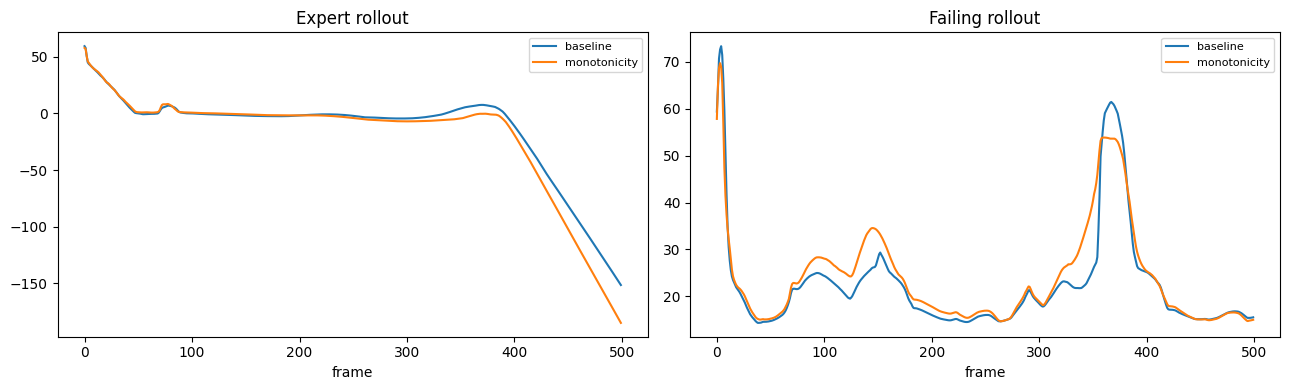

failing rollout minimum: baseline=14.3  monotonic=14.7


In [12]:
pred_mono = make_predictor(m_mono, s["x_mean"], s["x_std"], s["y_mean"], s["y_std"])
p_fail_mono, _ = rollout_preds(early_pol, pred_mono)
p_exp_mono, _  = rollout_preds(expert_pol, pred_mono)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(p_exp_full, label="baseline"); axes[0].plot(p_exp_mono, label="monotonicity")
axes[0].set_title("Expert rollout"); axes[0].legend(fontsize=8); axes[0].set_xlabel("frame")
axes[1].plot(p_fail_full, label="baseline"); axes[1].plot(p_fail_mono, label="monotonicity")
axes[1].set_title("Failing rollout"); axes[1].legend(fontsize=8); axes[1].set_xlabel("frame")
plt.tight_layout(); plt.show()

print(f"failing rollout minimum: baseline={p_fail_full.min():.1f}  monotonic={p_fail_mono.min():.1f}")

## D. Off-path data

**Why:** every diagnostic has pointed here. The dataset contains only states on
or near one successful path; the RL policy starts nowhere near it, and the
model's output there is extrapolation.

**Method:** collect rollouts with action noise at several magnitudes and from
early checkpoints, keeping them regardless of outcome. Successes get the normal
first-success anchored label; failures get a censored ceiling meaning "at least
this far". Run only after A-C, since it is the most expensive and the others may
localize the problem more cheaply.

In [6]:
CENSOR_LABEL = 300.0        # "at least this far" for episodes that never succeed
NOISE_LEVELS = [0.0, 0.1, 0.25, 0.5]
EPISODES_PER_LEVEL = 15

def collect_offpath(policy, noise_std, n_eps, start_seed=0, max_steps=300):
    out = []
    env = make_fixed_scene_env()
    for k in range(n_eps):
        obs, _ = env.reset(seed=start_seed + k)
        obs_list, first_success = [], None
        for t in range(max_steps):
            obs_list.append(obs.copy())
            a, _ = policy.predict(obs, deterministic=True)
            if noise_std > 0:
                a = np.clip(a + np.random.normal(0, noise_std, size=a.shape),
                            env.action_space.low, env.action_space.high)
            obs, _, term, trunc, info = env.step(a)
            if info.get(SUCCESS_KEY, 0) and first_success is None:
                first_success = t
            if term or trunc:
                break
        if first_success is not None:
            labels = np.array([max(0, first_success - t) for t in range(len(obs_list))],
                               dtype=np.float32)
        else:
            labels = np.full(len(obs_list), CENSOR_LABEL, dtype=np.float32)
        out.append(dict(obs=np.array(obs_list, dtype=np.float32), labels=labels,
                          succeeded=first_success is not None, noise=noise_std))
    env.close()
    return out

offpath = []
seed = 10_000
for pol, tag in [(expert_pol, "final"), (early_pol, "early")]:
    for ns in NOISE_LEVELS:
        eps = collect_offpath(pol, ns, EPISODES_PER_LEVEL, start_seed=seed)
        seed += EPISODES_PER_LEVEL
        n_succ = sum(e["succeeded"] for e in eps)
        print(f"{tag:6s} noise={ns:.2f}: {n_succ}/{len(eps)} succeeded")
        offpath.extend(eps)

print(f"\ntotal off-path episodes: {len(offpath)}, "
      f"{sum(e['succeeded'] for e in offpath)} successful")

final  noise=0.00: 15/15 succeeded
final  noise=0.10: 15/15 succeeded
final  noise=0.25: 15/15 succeeded
final  noise=0.50: 15/15 succeeded
early  noise=0.00: 0/15 succeeded
early  noise=0.10: 0/15 succeeded
early  noise=0.25: 0/15 succeeded
early  noise=0.50: 0/15 succeeded

total off-path episodes: 120, 60 successful


augmented dataset: 45457 rows (36000 off-path, 79%)
  ./checkpoints/t2s_offpath: best val MSE(norm)=0.0058, stopped epoch 90


d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


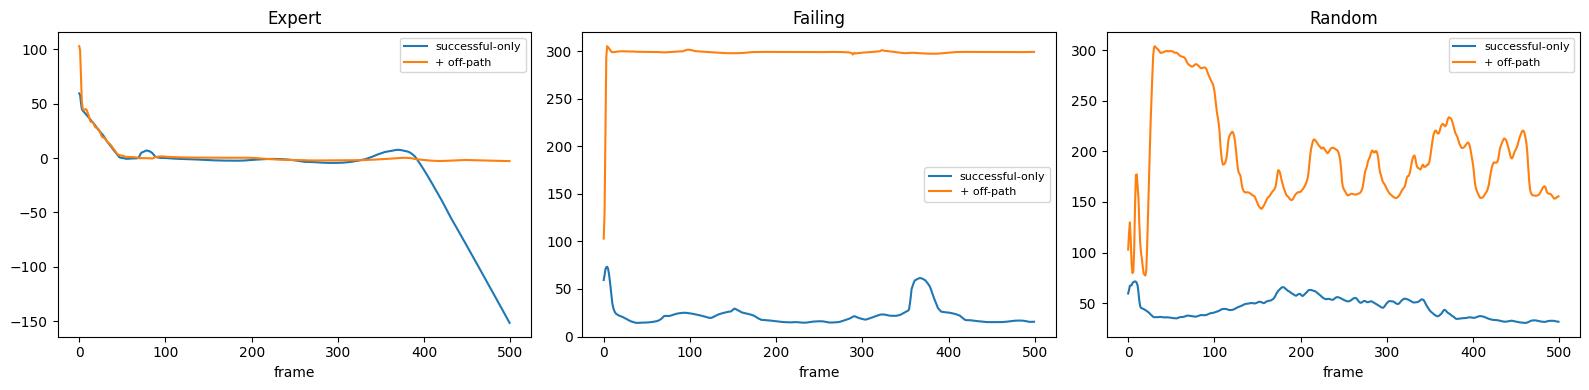

failing rollout minimum: successful-only=14.3  with off-path=102.9
random rollout minimum : successful-only=30.4  with off-path=77.2


In [7]:
X_off = np.concatenate([e["obs"] for e in offpath])
y_off = np.concatenate([e["labels"] for e in offpath])
ep_off = np.concatenate([np.full(len(e["obs"]), len(np.unique(episode_ids)) + i)
                          for i, e in enumerate(offpath)])

X_aug = np.concatenate([X, X_off])
y_aug = np.concatenate([y_steps, y_off])
ep_aug = np.concatenate([episode_ids, ep_off])
print(f"augmented dataset: {X_aug.shape[0]} rows "
      f"({X_off.shape[0]} off-path, {100*X_off.shape[0]/X_aug.shape[0]:.0f}%)")

s_aug = split_and_normalize(X_aug, y_aug, ep_aug)
m_aug, v_aug = train_model(s_aug["Xtr"], s_aug["ytr"], s_aug["Xva"], s_aug["yva"],
                            OBS_DIM, "./checkpoints/t2s_offpath")
np.savez("./checkpoints/t2s_offpath/normalization.npz",
         X_mean=s_aug["x_mean"], X_std=s_aug["x_std"],
         y_mean=s_aug["y_mean"], y_std=s_aug["y_std"])

pred_aug = make_predictor(m_aug, s_aug["x_mean"], s_aug["x_std"],
                           s_aug["y_mean"], s_aug["y_std"])
p_fail_aug, _ = rollout_preds(early_pol, pred_aug)
p_exp_aug, s_e = rollout_preds(expert_pol, pred_aug)
p_rand_aug, _ = rollout_preds(None, pred_aug, random_policy=True)
p_rand_full, _ = rollout_preds(None, pred_full, random_policy=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (title, base, aug) in zip(axes, [
        ("Expert", p_exp_full, p_exp_aug),
        ("Failing", p_fail_full, p_fail_aug),
        ("Random", p_rand_full, p_rand_aug)]):
    ax.plot(base, label="successful-only"); ax.plot(aug, label="+ off-path")
    ax.set_title(title); ax.set_xlabel("frame"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"failing rollout minimum: successful-only={p_fail_full.min():.1f}  "
      f"with off-path={p_fail_aug.min():.1f}")
print(f"random rollout minimum : successful-only={p_rand_full.min():.1f}  "
      f"with off-path={p_rand_aug.min():.1f}")

## Deciding what to carry into the reward

The number to compare across A-D is **the failing rollout's minimum predicted
steps**. Baseline is ~11 — the model rating a permanently stalled arm as nearly
done, which is what gave hovering 87% of the expert's reward.

Whichever variant raises that number most while keeping expert predictions
accurate is the one worth putting behind the reward wrapper. Re-run Section 5
of `3_train_policy_v6.ipynb` with that model to confirm the expert/failing/random
totals separate more cleanly before committing to another training run.